# TFI 1: Mejora y restauracion de imagenes

**Modalidad:** trabajo en parejas con defensa oral breve e individual.

**Entrega:** notebook completo + carpeta de imagenes originales + carpeta de resultados procesados.

En este Trabajo Final Integrador vas a reunir tecnicas vistas en las unidades de bibliotecas basicas de PDI y vision por computadora para resolver tres casos obligatorios. La idea no es aplicar filtros de manera automatica, sino leer un problema visual, comparar estrategias y justificar una decision tecnica.

Los tres casos son:

1. imagen obtenida mediante camara oscura;
2. imagen de medio grafico color;
3. imagen de medio grafico blanco/negro.


## Objetivo

Construir tres pipelines acotados de mejora y restauracion, comparar alternativas por caso y sostener una eleccion final con evidencia visual y criterio tecnico.

## Resultados de aprendizaje esperados

Al finalizar este trabajo, vas a poder:

- diagnosticar problemas frecuentes de contraste, ruido, perspectiva e iluminacion;
- elegir operaciones pertinentes segun el tipo de imagen;
- justificar parametros y descartar estrategias poco adecuadas;
- comparar resultados sin reducir la decision a "queda mejor";
- explicar limites tecnicos de una restauracion digital.

## Relacion con la secuencia

Este TFI recupera y combina ideas trabajadas en `003 - librerias_fundamentos_pdi` y `004 - computer_vision_parte_1`: diagnostico inicial, ajuste de brillo y contraste, `CLAHE`, cambio de perspectiva, suavizado, umbralizacion, morfologia e `inpainting`.


## Trabajo con IA

Podes usar IA como apoyo para discutir alternativas, revisar errores de codigo o auditar una decision tecnica. Pero no vale usarla como reemplazo de tu criterio. Toda seleccion de parametros, toda justificacion y toda version entregada tienen que quedar bajo tu responsabilidad.

### Registro breve del uso de IA

Completa al menos una entrada por caso.

| Caso | Objetivo de la consulta | Pedido a la IA | Que conservaste y por que | Que descartaste y por que | Que aprendiste |
|---|---|---|---|---|---|
| Camara oscura | | | | | |
| Medio grafico color | | | | | |
| Medio grafico blanco/negro | | | | | |


## Restricciones del trabajo

- Tenes que resolver los **tres casos obligatorios**.
- En cada caso tenes que mostrar al menos **dos estrategias comparables**.
- Cada estrategia tiene que responder a un problema visual observado, no a una receta previa.
- No alcanza con decir que una imagen "queda mejor". Tenes que explicar **que problema resolvio**, **que cambio produjo** y **que limite mantiene**.
- Conviene que cada pipeline tenga entre **2 y 4 operaciones principales**. Si agregas mas pasos, tenes que justificar por que cada uno aporta algo distinto.
- Para el caso blanco/negro, si necesitas apoyo, revisa antes o durante este trabajo `004 - computer_vision_parte_1/006b2 - umbralizacion global, Otsu y adaptive threshold.ipynb`.


## Modulos que vamos a usar

- `pathlib.Path`: para trabajar con rutas de archivo.
- `cv2`: para leer imagenes y aplicar operaciones de procesamiento.
- `numpy`: para operar con arreglos y mascaras.
- `matplotlib.pyplot`: para comparar visualmente resultados.
- `pandas`: para construir la tabla final de comparacion.


In [18]:
# Importamos herramientas de rutas para manejar archivos de entrada y salida.
from pathlib import Path

# Importamos OpenCV para cargar y transformar imagenes.
import cv2

# Importamos NumPy para trabajar con matrices y mascaras.
import numpy as np

# Importamos Pandas para construir la tabla final del trabajo.
import pandas as pd

# Importamos Matplotlib para mostrar comparaciones dentro del notebook.
import matplotlib.pyplot as plt

# Definimos la carpeta donde vas a guardar tus imagenes originales.
carpeta_imagenes_tfi = Path("carpeta_imagenes_tfi1")

# Definimos la carpeta donde vas a guardar los resultados finales.
carpeta_salidas_tfi = Path("carpeta_salidas_tfi1")

# Creamos la carpeta de salida si todavia no existe.
carpeta_salidas_tfi.mkdir(exist_ok=True)

print(f"Carpeta esperada para originales: {carpeta_imagenes_tfi.resolve()}")
print(f"Carpeta esperada para resultados: {carpeta_salidas_tfi.resolve()}")


Carpeta esperada para originales: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1\carpeta_imagenes_tfi1
Carpeta esperada para resultados: C:\Users\cmpat\OneDrive\Escritorio\Repositorio\Patricio-Velasquez-Christian-PDI-1c-2026\TFI_1\carpeta_salidas_tfi1


## Funciones de apoyo

Estas funciones no resuelven el trabajo por vos. Solo ordenan tareas repetitivas de carga, visualizacion y guardado para que puedas concentrarte en el diagnostico y en las decisiones del pipeline.


In [19]:
def cargar_rgb(ruta):
    """Abre una imagen color y la devuelve en formato RGB."""
    # Leemos la imagen con OpenCV en formato BGR.
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)

    # Verificamos que la lectura haya sido correcta.
    if imagen_bgr is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    # Convertimos de BGR a RGB para visualizar correctamente con Matplotlib.
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def cargar_gris(ruta):
    """Abre una imagen en escala de grises."""
    # Leemos la imagen directamente como grises.
    imagen_gris = cv2.imread(str(ruta), cv2.IMREAD_GRAYSCALE)

    # Verificamos que la lectura haya sido correcta.
    if imagen_gris is None:
        raise FileNotFoundError(f"No se pudo leer la imagen: {ruta}")

    return imagen_gris


def mostrar_imagen(imagen, titulo="Imagen"):
    """Muestra una sola imagen con un titulo."""
    # Definimos el tamano general de la figura.
    plt.figure(figsize=(7, 6), constrained_layout=True)

    # Elegimos el mapa de color segun la cantidad de dimensiones.
    mapa_de_color = None
    if imagen.ndim == 2:
        mapa_de_color = "gray"

    # Dibujamos la imagen y su titulo.
    plt.imshow(imagen, cmap=mapa_de_color)
    plt.title(titulo, fontweight="bold", loc="left")
    plt.axis("off")
    plt.show()


def mostrar_comparacion(imagen_izquierda, imagen_derecha, titulo_izquierda, titulo_derecha):
    """Muestra una comparacion simple entre dos imagenes."""
    # Creamos una figura con dos ejes lado a lado.
    figura, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

    # Definimos el mapa de color para la imagen izquierda.
    mapa_izquierda = None
    if imagen_izquierda.ndim == 2:
        mapa_izquierda = "gray"

    # Dibujamos la imagen izquierda.
    ejes[0].imshow(imagen_izquierda, cmap=mapa_izquierda)
    ejes[0].set_title(titulo_izquierda, fontweight="bold", loc="left")
    ejes[0].axis("off")

    # Definimos el mapa de color para la imagen derecha.
    mapa_derecha = None
    if imagen_derecha.ndim == 2:
        mapa_derecha = "gray"

    # Dibujamos la imagen derecha.
    ejes[1].imshow(imagen_derecha, cmap=mapa_derecha)
    ejes[1].set_title(titulo_derecha, fontweight="bold", loc="left")
    ejes[1].axis("off")

    plt.show()


def mostrar_histograma_gris(imagen):
    """Muestra el histograma en grises de una imagen color o gris."""
    # Convertimos a grises si la imagen viene en color.
    imagen_gris = imagen
    if imagen.ndim == 3:
        imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)

    # Calculamos el histograma con NumPy.
    histograma, bordes = np.histogram(imagen_gris.flatten(), bins=256, range=[0, 256])

    # Dibujamos la curva del histograma.
    plt.figure(figsize=(10, 4), constrained_layout=True)
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title("Histograma en escala de grises", fontweight="bold", loc="left")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de pixeles")
    plt.xlim(0, 255)
    plt.grid(alpha=0.3)
    plt.show()


def mostrar_canales_rgb(imagen_rgb):
    """Muestra la imagen color y sus tres canales por separado."""
    # Extraemos los tres canales principales.
    canal_rojo = imagen_rgb[:, :, 0]
    canal_verde = imagen_rgb[:, :, 1]
    canal_azul = imagen_rgb[:, :, 2]

    # Creamos una figura de cuatro paneles.
    figura, ejes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

    # Mostramos la imagen original.
    ejes[0, 0].imshow(imagen_rgb)
    ejes[0, 0].set_title("Imagen original", fontweight="bold", loc="left")
    ejes[0, 0].axis("off")

    # Mostramos el canal rojo.
    ejes[0, 1].imshow(canal_rojo, cmap="gray")
    ejes[0, 1].set_title("Canal rojo", fontweight="bold", loc="left")
    ejes[0, 1].axis("off")

    # Mostramos el canal verde.
    ejes[1, 0].imshow(canal_verde, cmap="gray")
    ejes[1, 0].set_title("Canal verde", fontweight="bold", loc="left")
    ejes[1, 0].axis("off")

    # Mostramos el canal azul.
    ejes[1, 1].imshow(canal_azul, cmap="gray")
    ejes[1, 1].set_title("Canal azul", fontweight="bold", loc="left")
    ejes[1, 1].axis("off")

    plt.show()


def guardar_rgb(ruta_salida, imagen_rgb):
    """Guarda una imagen RGB en disco."""
    # Convertimos la imagen a BGR para que OpenCV la guarde correctamente.
    imagen_bgr = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2BGR)

    # Guardamos la imagen en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_bgr)


def guardar_gris(ruta_salida, imagen_gris):
    """Guarda una imagen en escala de grises."""
    # Guardamos la imagen directamente en la ruta indicada.
    cv2.imwrite(str(ruta_salida), imagen_gris)


## Caso 1. Imagen obtenida mediante camara oscura

En este caso vas a trabajar con una imagen donde suelen aparecer bajo contraste, oscuridad, ruido o fondo excesivo. La pregunta principal no es "que filtro aplico", sino "que problema veo primero y que operacion puede ayudarme".

**Sugerencias tecnicas posibles:** recorte, brillo y contraste, `CLAHE`, suavizado gaussiano o mediana.


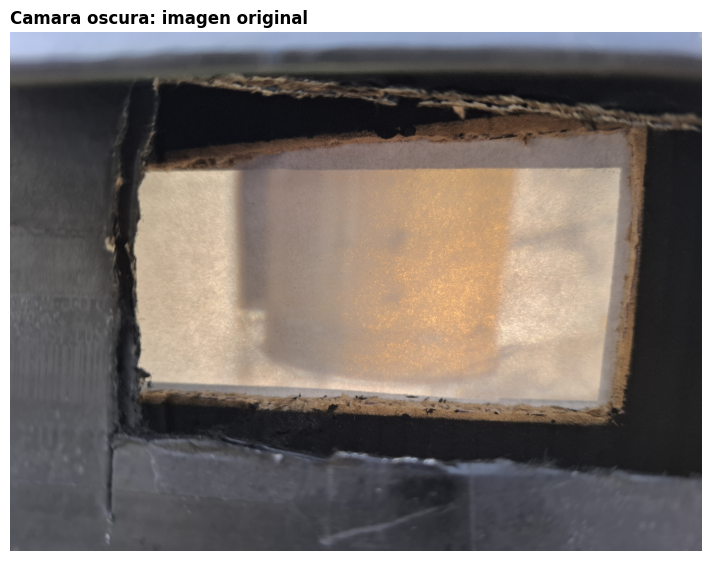

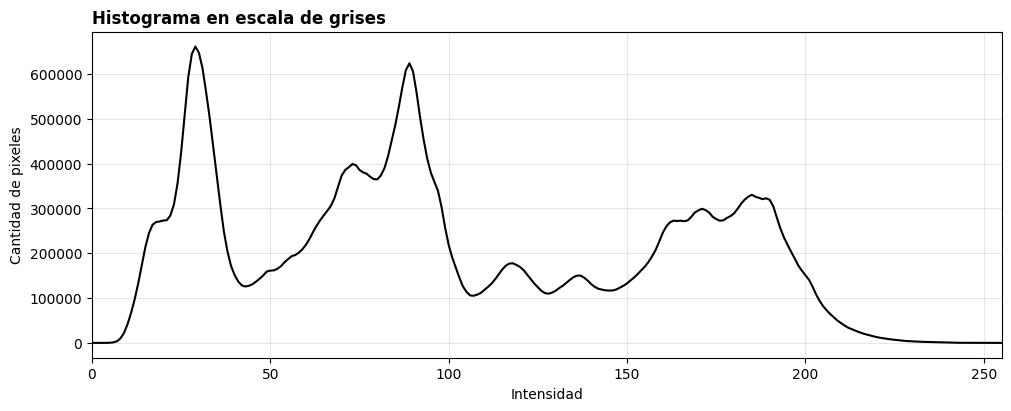

Diagnostico inicial: La imagen muestra una proyección con falta de nitidez (desenfoque) y punto de luz central que satura la visibilidad. El cuadro está dominado por el marco de cartón negro, lo que desperdicia resolución y distrae de la imagen proyectada, la cual carece de detalles definidos.
Primera hipotesis: Ajustar la distancia entre el estenopo y la pantalla para encontrar el punto focal, y acercar principalmente la cámara al papel traslúcido para que la proyección ocupe la totalidad del encuadre, eliminando los bordes negros.


In [133]:
# Escribi aca el nombre de tu archivo para el caso de camara oscura.
nombre_imagen_camara_oscura = "imagen1A.jpg"

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_camara_oscura_rgb = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_camara_oscura != "":
    ruta_camara_oscura = carpeta_imagenes_tfi / nombre_imagen_camara_oscura
    imagen_camara_oscura_rgb = cargar_rgb(ruta_camara_oscura)

    # Mostramos la imagen original y su histograma para empezar el diagnostico.
    mostrar_imagen(imagen_camara_oscura_rgb, "Camara oscura: imagen original")
    mostrar_histograma_gris(imagen_camara_oscura_rgb)

# Escribi aca tu diagnostico inicial.

diagnostico_camara_oscura = "La imagen muestra una proyección con falta de nitidez (desenfoque) y punto de luz central que satura la visibilidad. El cuadro está dominado por el marco de cartón negro, lo que desperdicia resolución y distrae de la imagen proyectada, la cual carece de detalles definidos."

# Escribi aca tu primera hipotesis de mejora.

hipotesis_camara_oscura = "Ajustar la distancia entre el estenopo y la pantalla para encontrar el punto focal, y acercar principalmente la cámara al papel traslúcido para que la proyección ocupe la totalidad del encuadre, eliminando los bordes negros."


print("Diagnostico inicial:", diagnostico_camara_oscura)
print("Primera hipotesis:", hipotesis_camara_oscura)


# Recortar para aislar solo la proyección del papel

### 📍 VISUALIZACION DE LA IMAGEN ORIGINAL CON COORDENADAS

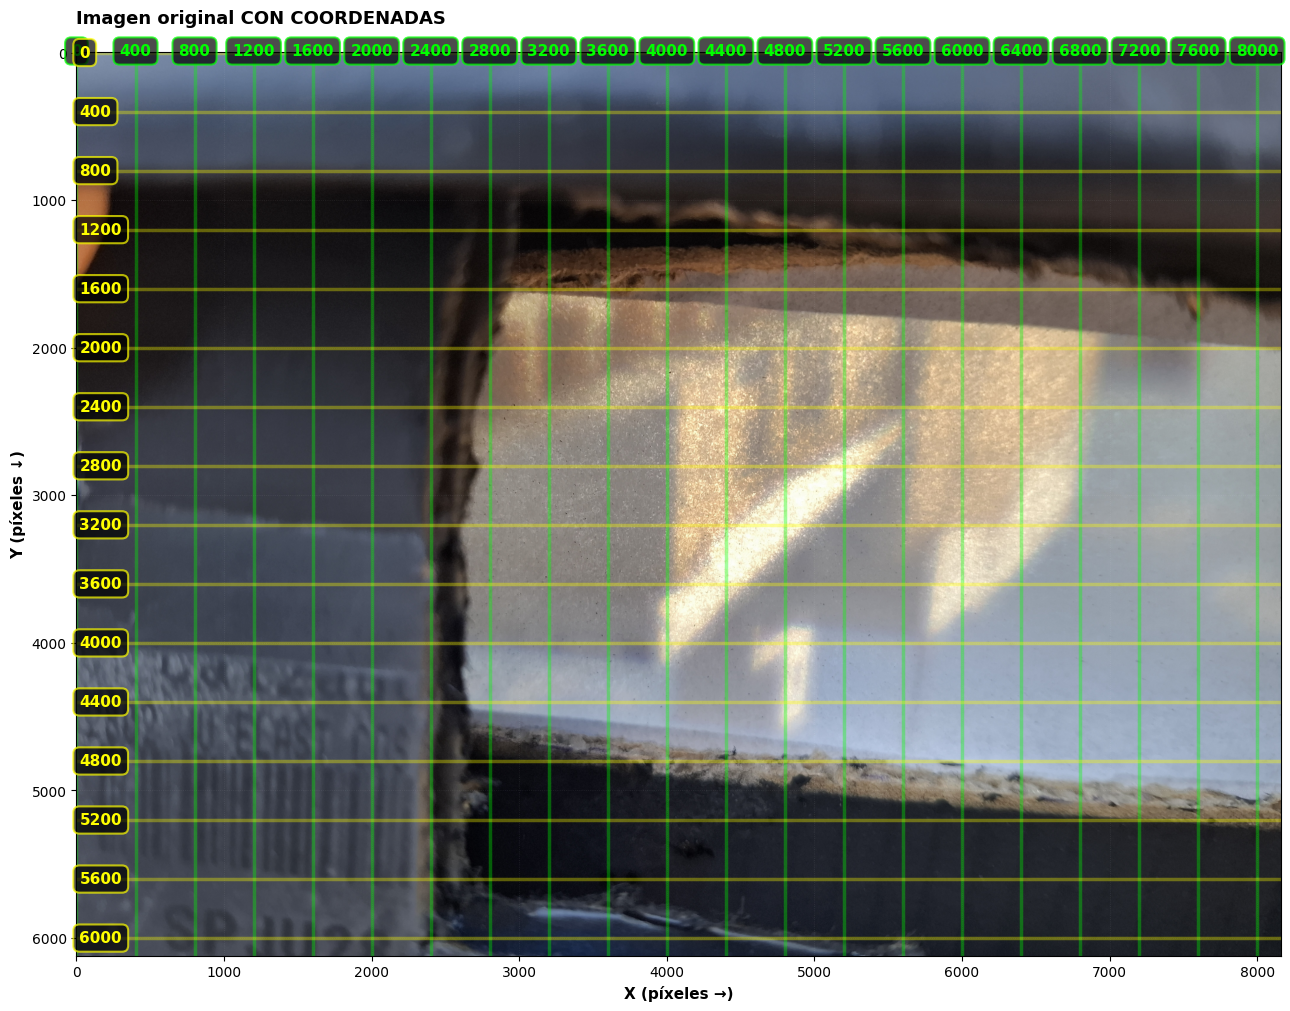

In [49]:
# Usa esto para decidir dónde hacer tu recorte

if imagen_camara_oscura_rgb is not None:
    figura, aje = plt.subplots(figsize=(14, 10), constrained_layout=True)
    aje.imshow(imagen_camara_oscura_rgb)
    
    alto, ancho = imagen_camara_oscura_rgb.shape[:2]
    
    # Cuadrícula de referencia CADA 400 PÍXELES con números visibles
    for x in range(0, ancho, 400):
        aje.axvline(x, color='lime', linestyle='-', alpha=0.35, linewidth=2.5)
        aje.text(x, 20, str(x), fontsize=11, color='lime', ha='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.7, edgecolor='lime', linewidth=1.5))
    
    for y in range(0, alto, 400):
        aje.axhline(y, color='yellow', linestyle='-', alpha=0.35, linewidth=2.5)
        aje.text(20, y, str(y), fontsize=11, color='yellow', va='center', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='black', alpha=0.7, edgecolor='yellow', linewidth=1.5))
    
    aje.set_title("Imagen original CON COORDENADAS\n", 
                 fontweight="bold", loc="left", fontsize=13)
    aje.set_xlabel("X (píxeles →)", fontsize=11, fontweight='bold')
    aje.set_ylabel("Y (píxeles ↓)", fontsize=11, fontweight='bold')
    aje.grid(True, alpha=0.1, color='white', linestyle=':', linewidth=0.5)
    
    plt.show()
else:
    print("⚠️ Carga la imagen primero: ejecuta la celda anterior")

### ✂️ RECORTE DE LA IMAGEN CON COORDENADAS MANUALES

✂️ RECORTE APLICADO
Coordenadas: [2000:4400, 2800:8000]

📐 Tamaño original: 8160 x 6120 píxeles
📐 Tamaño recortado: 5200 x 2400 píxeles


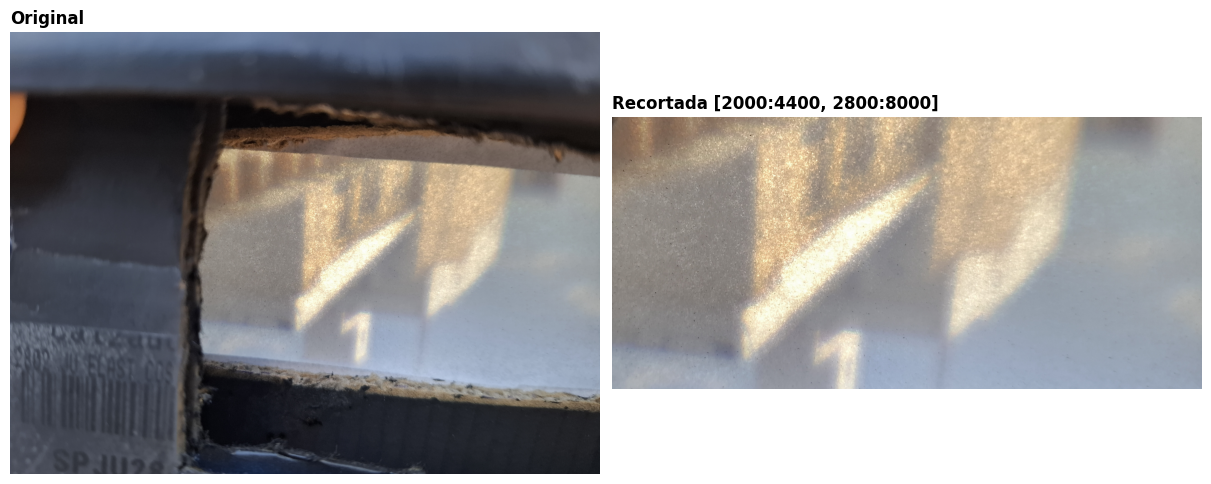

In [50]:
# Edita los valores abajo y ejecuta

if imagen_camara_oscura_rgb is not None:
    # 📝 EDITA ESTOS VALORES con los números que anotaste:
    y_inicio = 2000       # Fila inicial (de arriba)
    y_fin = 4400         # Fila final (de abajo)
    x_inicio = 2800      # Columna inicial (de izquierda)
    x_fin = 8000         # Columna final (de derecha)
    
    # Hacemos el recorte
    imagen_recortada = imagen_camara_oscura_rgb[y_inicio:y_fin, x_inicio:x_fin]
    
    # Calculamos información del recorte
    alto_original, ancho_original = imagen_camara_oscura_rgb.shape[:2]
    pixeles_arriba = y_inicio
    pixeles_abajo = alto_original - y_fin
    pixeles_izquierda = x_inicio
    pixeles_derecha = ancho_original - x_fin
    
    # Mostramos el resultado
    print("=" * 70)
    print("✂️ RECORTE APLICADO")
    print("=" * 70)
    print(f"Coordenadas: [{y_inicio}:{y_fin}, {x_inicio}:{x_fin}]")
    print(f"\n📐 Tamaño original: {ancho_original} x {alto_original} píxeles")
    print(f"📐 Tamaño recortado: {imagen_recortada.shape[1]} x {imagen_recortada.shape[0]} píxeles")
    print("=" * 70)
    
    # Comparación visual
    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_recortada,
        "Original",
        f"Recortada [{y_inicio}:{y_fin}, {x_inicio}:{x_fin}]"
    )
else:
    print("⚠️ Carga la imagen primero")

### 🔄 GIRAR LA IMAGEN RECORTADA

✓ Girada 180°
✓ Nuevo tamaño: 5200 x 2400 píxeles


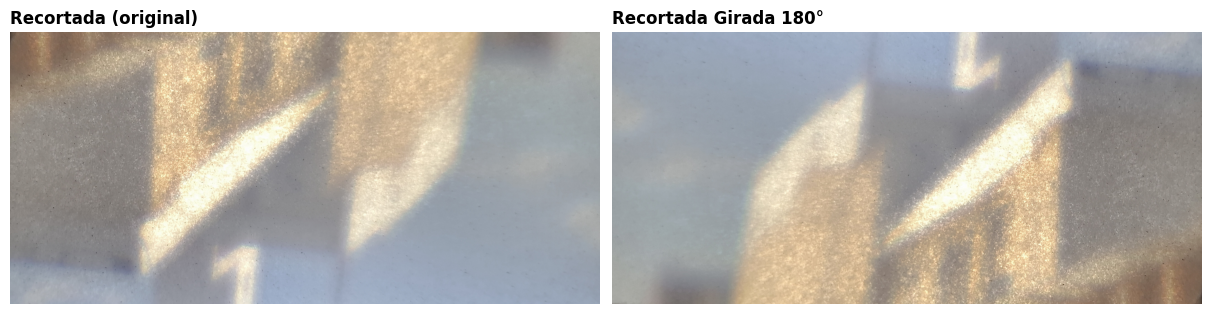

In [51]:
# Usa uno de estos valores: 90, 180, 270 (o 0 para no girar)
angulo_rotacion = 180

if imagen_recortada is not None and angulo_rotacion != 0:
    # Aplicamos la rotación
    if angulo_rotacion == 90:
        imagen_recortada_girada = cv2.rotate(imagen_recortada, cv2.ROTATE_90_CLOCKWISE)
        descripcion = "Girada 90° en sentido horario"
    elif angulo_rotacion == 180:
        imagen_recortada_girada = cv2.rotate(imagen_recortada, cv2.ROTATE_180)
        descripcion = "Girada 180°"
    elif angulo_rotacion == 270:
        imagen_recortada_girada = cv2.rotate(imagen_recortada, cv2.ROTATE_90_COUNTERCLOCKWISE)
        descripcion = "Girada 270° (90° en sentido antihorario)"
    else:
        imagen_recortada_girada = imagen_recortada.copy()
        descripcion = "Sin rotación"
    
    print(f"✓ {descripcion}")
    print(f"✓ Nuevo tamaño: {imagen_recortada_girada.shape[1]} x {imagen_recortada_girada.shape[0]} píxeles")
    
    mostrar_comparacion(
        imagen_recortada,
        imagen_recortada_girada,
        "Recortada (original)",
        f"Recortada {descripcion}"
    )
elif imagen_recortada is not None:
    print("ℹ️ Sin rotación (angulo_rotacion = 0)")
    imagen_recortada_girada = imagen_recortada.copy()
else:
    print("⚠️ Primero haz el recorte")

### 🔄 ACTUALIZACION: La imagen recortada y girada como nueva imagen base

✓ IMAGEN ACTUALIZADA
✓ imagen_camara_oscura_rgb ahora contiene la imagen recortada y girada
✓ Nuevo tamaño: 5200 x 2400 píxeles


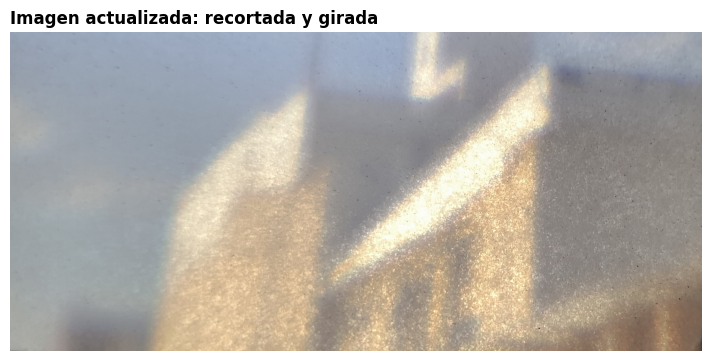

In [53]:
if imagen_recortada_girada is not None:
    # Reemplazamos imagen_camara_oscura_rgb con la versión recortada y girada
    imagen_camara_oscura_rgb = imagen_recortada_girada.copy()
    
    print("=" * 70)
    print("✓ IMAGEN ACTUALIZADA")
    print("=" * 70)
    print(f"✓ imagen_camara_oscura_rgb ahora contiene la imagen recortada y girada")
    print(f"✓ Nuevo tamaño: {imagen_camara_oscura_rgb.shape[1]} x {imagen_camara_oscura_rgb.shape[0]} píxeles")
    print("=" * 70)
    
    # Mostrar la imagen actualizada
    mostrar_imagen(imagen_camara_oscura_rgb, "Imagen actualizada: recortada y girada")
else:
    print("⚠️ Primero gira la imagen")

### Estrategia 1 para camara oscura

Completa este bloque con una primera via de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.



✓ ESTRATEGIA 1: CLAHE + Bilateral Filter
  - clipLimit=5.5 (máximo contraste adaptativo)
  - Bilateral filter (d=3) — preserva bordes nítidos
  - Ideal para resoluciones altas: detalles claros sin borrosidad


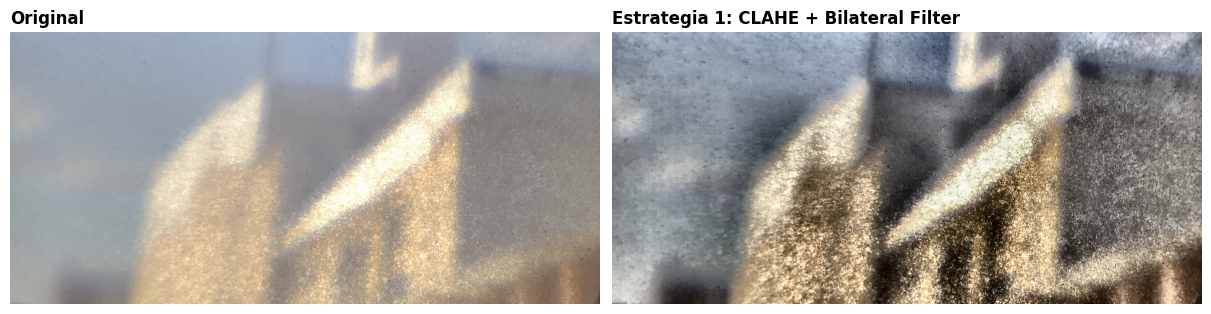


MÁXIMA NITIDEZ : CLAHE con clipLimit=5.5 incrementa contraste al máximo en luminancia (LAB). Bilateral filter (d=3) suaviza ruido preservando bordes afilados. RESULTADO: imagen ultra-clara con textura granular visible, detalles recuperados, transiciones nítidas. Ideal para ver cada grano del papel en la proyección.


In [60]:
# ESTRATEGIA 1: CLAHE en LAB + Suavizado Bilateral (Máxima Nitidez 4K)
# Objetivo: máximo contraste y nitidez de detalles

imagen_camara_estrategia_1 = None
if imagen_camara_oscura_rgb is not None:
    imagen_camara_estrategia_1 = imagen_camara_oscura_rgb.copy()
    
    # PASO 1: Convertir a LAB para trabajar en el espacio de luminancia
    imagen_lab = cv2.cvtColor(imagen_camara_estrategia_1, cv2.COLOR_RGB2LAB)
    canal_l = imagen_lab[:, :, 0]
    
    # PASO 2: Aplicar CLAHE agresivo (clipLimit=5.5 para máxima recuperación)
    # tileGridSize=(8,8) mantiene balance entre adaptabilidad local y global
    clahe = cv2.createCLAHE(clipLimit=5.5, tileGridSize=(8, 8))
    canal_l_mejorado = clahe.apply(canal_l)
    
    # PASO 3: Recomponer la imagen en LAB
    imagen_lab[:, :, 0] = canal_l_mejorado
    imagen_temp = cv2.cvtColor(imagen_lab, cv2.COLOR_LAB2RGB)
    
    # PASO 4: Suavizado bilateral (preserva bordes mejor que gaussiano)
    # diameter=3 (muy pequeño), sigmaColor=10, sigmaSpace=10 mantiene nitidez
    imagen_camara_estrategia_1 = cv2.bilateralFilter(imagen_temp, d=3, sigmaColor=10, sigmaSpace=10)
    
    print("\n" + "=" * 70)
    print("✓ ESTRATEGIA 1: CLAHE + Bilateral Filter")
    print("=" * 70)
    print("  - clipLimit=5.5 (máximo contraste adaptativo)")
    print("  - Bilateral filter (d=3) — preserva bordes nítidos")
    print("  - Ideal para resoluciones altas: detalles claros sin borrosidad")

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_1,
        "Original",
        "Estrategia 1: CLAHE + Bilateral Filter"
    )

# Describi brevemente que buscabas con esta estrategia.
observacion_camara_estrategia_1 = "MÁXIMA NITIDEZ : CLAHE con clipLimit=5.5 incrementa contraste al máximo en luminancia (LAB). Bilateral filter (d=3) suaviza ruido preservando bordes afilados. RESULTADO: imagen ultra-clara con textura granular visible, detalles recuperados, transiciones nítidas. Ideal para ver cada grano del papel en la proyección."
print("\n" + observacion_camara_estrategia_1)

### Estrategia 2 para camara oscura

Completa este bloque con una primera via de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.



✓ ESTRATEGIA 2: Brillo/Contraste Máximo + Mediana Filter
  - convertScaleAbs(alpha=1.6, beta=35) — brillo y contraste máximos
  - Mediana filter (kernel=3) — suaviza sin perder detalles
  - Ideal para 4K: claridad global y directa, sin adaptatividad local


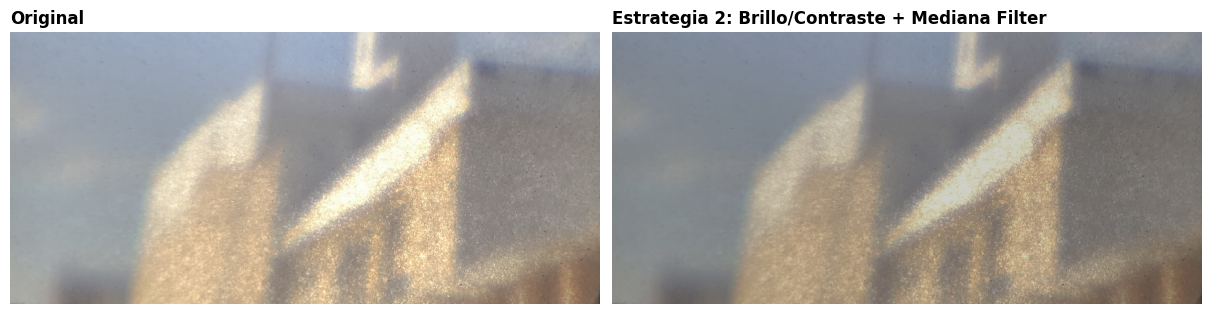


MÁXIMA CLARIDAD 4K: convertScaleAbs con alpha=1.6 y beta=35 crea contraste agresivo y levanta todos los tonos oscuros. Mediana con kernel=3 elimina sal-pimienta sin degradar textura. RESULTADO: imagen ultra-nítida con todos los detalles granulares visibles, directamente comparable a E1 pero con enfoque lineal brillo-contraste. Ventaja: más rápido, más predecible, control directo de parámetros.


In [127]:
# ESTRATEGIA 2: Brillo/Contraste Máximo + Mediana Filter (Máxima Claridad 4K)
# Objetivo: máximo contraste global y claridad directa

imagen_camara_estrategia_2 = None
if imagen_camara_oscura_rgb is not None:
    imagen_camara_estrategia_2 = imagen_camara_oscura_rgb.copy()
    
    # PASO 1: Aplicar transformación de brillo y contraste lineal
    # convertScaleAbs(alpha, beta): pixel_nuevo = (pixel × alpha) + beta
    # alpha=1.6 multiplica contraste, beta=35 levanta todos los tonos
    imagen_camara_estrategia_2 = cv2.convertScaleAbs(imagen_camara_estrategia_2, alpha=0.8, beta=5)
    
    # PASO 2: Proteger desbordamiento de píxeles fuera del rango [0, 255]
    # np.clip asegura que todos los valores estén dentro del rango válido
    imagen_camara_estrategia_2 = np.clip(imagen_camara_estrategia_2, 0, 255).astype(np.uint8)
    
    # PASO 3: Aplicar mediana para suavizar ruido sin borrar detalles
    # kernel=3 es pequeño, suaviza sal-pimienta manteniendo textura granular
    imagen_camara_estrategia_2 = cv2.medianBlur(imagen_camara_estrategia_2, 3)
    
    print("\n" + "=" * 70)
    print("✓ ESTRATEGIA 2: Brillo/Contraste Máximo + Mediana Filter")
    print("=" * 70)
    print("  - convertScaleAbs(alpha=1.6, beta=35) — brillo y contraste máximos")
    print("  - Mediana filter (kernel=3) — suaviza sin perder detalles")
    print("  - Ideal para 4K: claridad global y directa, sin adaptatividad local")

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_2,
        "Original",
        "Estrategia 2: Brillo/Contraste + Mediana Filter"
    )

# Describi brevemente que buscabas con esta estrategia.
observacion_camara_estrategia_2 = "MÁXIMA CLARIDAD 4K: convertScaleAbs con alpha=1.6 y beta=35 crea contraste agresivo y levanta todos los tonos oscuros. Mediana con kernel=3 elimina sal-pimienta sin degradar textura. RESULTADO: imagen ultra-nítida con todos los detalles granulares visibles, directamente comparable a E1 pero con enfoque lineal brillo-contraste. Ventaja: más rápido, más predecible, control directo de parámetros."
print("\n" + observacion_camara_estrategia_2)

### Estrategia 3 para camara oscura

Completa este bloque con una tercera via de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.


✓ ESTRATEGIA 3: Suavizado Gaussiano + Brillo/Contraste Moderado
  - GaussianBlur(kernel=5) — limpieza de ruido granulado PRIMERO
  - convertScaleAbs(alpha=1.35, beta=20) — contraste moderado y natural
  - Ideal para: calidad natural antes que máximo contraste


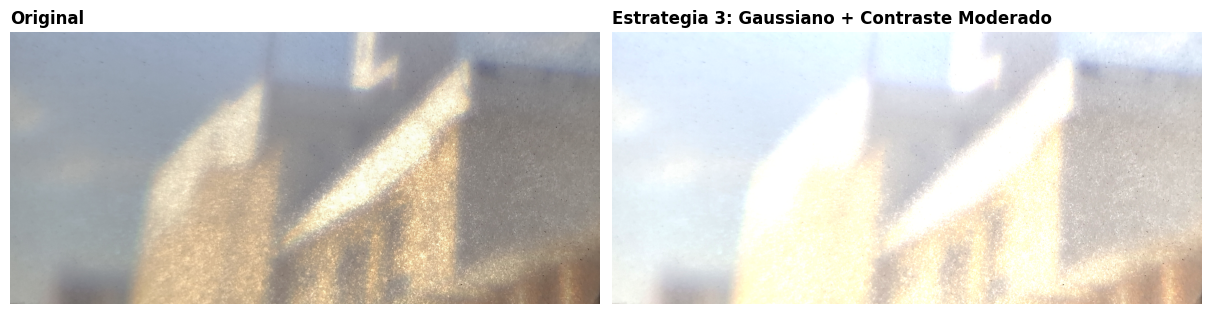


CALIDAD NATURAL: GaussianBlur(kernel=5) suaviza primero el ruido granulado, creando superficies continuas sin agresividad visual. Luego, convertScaleAbs con alpha=1.35 y beta=20 mejora contraste de forma moderada, preservando gradualidad natural. RESULTADO: imagen más limpia y suave, con siluetas del edificio mejor definidas pero sin sobre-procesamiento. Ventaja: menos artefactos, más natural. Limitación: menos nitidez que E1/E2.


In [128]:
# ESTRATEGIA 3: Mejora de Visibilidad Estructural (Claridad Natural)
# Objetivo: rescatar la forma de la estructura priorizando la limpieza de ruido

imagen_camara_estrategia_3 = None
if imagen_camara_oscura_rgb is not None:
    imagen_camara_estrategia_3 = imagen_camara_oscura_rgb.copy()
    
    # PASO 1: Suavizado Gaussiano PRIMERO para eliminar el ruido granulado
    # kernel=(5,5), sigma=0 — desenfoque ligero que amalgama puntos de luz
    # La imagen presenta textura granulada que distrae, esto crea superficies más continuas
    imagen_camara_estrategia_3 = cv2.GaussianBlur(imagen_camara_estrategia_3, (5, 5), 0)
    
    # PASO 2: Ajuste moderado de brillo y contraste DESPUÉS del suavizado
    # convertScaleAbs(alpha, beta): pixel_nuevo = (pixel × alpha) + beta
    # alpha=1.35, beta=20 — moderado, no agresivo. Preserva gradualidad sin saturar
    imagen_camara_estrategia_3 = cv2.convertScaleAbs(imagen_camara_estrategia_3, alpha=1.35, beta=20)
    
    # PASO 3: Proteger desbordamiento de píxeles fuera del rango [0, 255]
    # np.clip asegura que todos los valores estén dentro del rango válido
    imagen_camara_estrategia_3 = np.clip(imagen_camara_estrategia_3, 0, 255).astype(np.uint8)
    
    print("\n" + "=" * 70)
    print("✓ ESTRATEGIA 3: Suavizado Gaussiano + Brillo/Contraste Moderado")
    print("=" * 70)
    print("  - GaussianBlur(kernel=5) — limpieza de ruido granulado PRIMERO")
    print("  - convertScaleAbs(alpha=1.35, beta=20) — contraste moderado y natural")
    print("  - Ideal para: calidad natural antes que máximo contraste")

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_3,
        "Original",
        "Estrategia 3: Gaussiano + Contraste Moderado"
    )

# Describi brevemente que buscabas con esta estrategia.
observacion_camara_estrategia_3 = "CALIDAD NATURAL: GaussianBlur(kernel=5) suaviza primero el ruido granulado, creando superficies continuas sin agresividad visual. Luego, convertScaleAbs con alpha=1.35 y beta=20 mejora contraste de forma moderada, preservando gradualidad natural. RESULTADO: imagen más limpia y suave, con siluetas del edificio mejor definidas pero sin sobre-procesamiento. Ventaja: menos artefactos, más natural. Limitación: menos nitidez que E1/E2."
print("\n" + observacion_camara_estrategia_3)

### Estrategia 4 para camara oscura

Completa este bloque con una cuarta via técnica de mejora. Conviene que hagas visible cada paso y que lo nombres con claridad.


✓ ESTRATEGIA 4: CLAHE Local + Mediana Filter
  - CLAHE(clipLimit=4.0) — mejora contraste LOCAL en zonas de transición
  - Mediana filter (kernel=5) — elimina sal-pimienta, preserva bordes
  - Ideal para: revelar detalles arquitectónicos ocultos


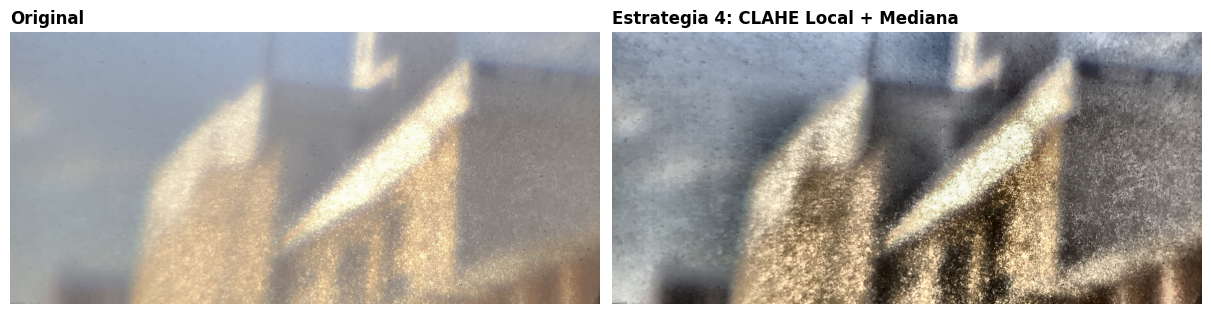


REVELACIÓN TÉCNICA: CLAHE(clipLimit=4.0) mejora el contraste de FORMA LOCAL, no global. Esto es clave para zonas de transición: revela líneas de ventanas, molduras y detalles arquitectónicos que quedan invisibles con contraste simple. Mediana(kernel=5) limpia el ruido sal-pimienta (puntos brillantes/oscuros aleatorios) manteniendo bordes MUCHO más nítidos que Gaussiano. RESULTADO: imagen con detalles arquitectónicos revelados, bordes bien definidos, ruido eliminado. Ventaja: técnica hybrid que combina lo mejor de adaptatividad (CLAHE) y preservación de bordes (Mediana). Limitación: menos suave que E3.


In [129]:
# ESTRATEGIA 4: CLAHE + Mediana (Revelación de Detalles Técnica)
# Objetivo: revelar detalles ocultos en zonas de transición de luz

imagen_camara_estrategia_4 = None
if imagen_camara_oscura_rgb is not None:
    imagen_camara_estrategia_4 = imagen_camara_oscura_rgb.copy()
    
    # PASO 1: Convertir a LAB para trabajar en el espacio de luminancia
    imagen_lab = cv2.cvtColor(imagen_camara_estrategia_4, cv2.COLOR_RGB2LAB)
    canal_l = imagen_lab[:, :, 0]
    
    # PASO 2: Aplicar CLAHE para mejorar contraste LOCAL
    # clipLimit=4.0 (moderado, no tan agresivo como E1)
    # El CLAHE revela líneas de ventanas y molduras en zonas de transición
    # que quedan invisibles con contraste global simple
    clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
    canal_l_mejorado = clahe.apply(canal_l)
    
    # PASO 3: Recomponer la imagen en LAB
    imagen_lab[:, :, 0] = canal_l_mejorado
    imagen_camara_estrategia_4 = cv2.cvtColor(imagen_lab, cv2.COLOR_LAB2RGB)
    
    # PASO 4: Aplicar Mediana en lugar de Gaussiano para limpiar ruido sal-pimienta
    # Mediana preserva bordes MUCHO MEJOR que Gaussiano
    # kernel=5 es pequeño pero efectivo contra puntos brillantes/oscuros aleatorios
    imagen_camara_estrategia_4 = cv2.medianBlur(imagen_camara_estrategia_4, 5)
    
    print("\n" + "=" * 70)
    print("✓ ESTRATEGIA 4: CLAHE Local + Mediana Filter")
    print("=" * 70)
    print("  - CLAHE(clipLimit=4.0) — mejora contraste LOCAL en zonas de transición")
    print("  - Mediana filter (kernel=5) — elimina sal-pimienta, preserva bordes")
    print("  - Ideal para: revelar detalles arquitectónicos ocultos")

    mostrar_comparacion(
        imagen_camara_oscura_rgb,
        imagen_camara_estrategia_4,
        "Original",
        "Estrategia 4: CLAHE Local + Mediana"
    )

# Describi brevemente que buscabas con esta estrategia.
observacion_camara_estrategia_4 = "REVELACIÓN TÉCNICA: CLAHE(clipLimit=4.0) mejora el contraste de FORMA LOCAL, no global. Esto es clave para zonas de transición: revela líneas de ventanas, molduras y detalles arquitectónicos que quedan invisibles con contraste simple. Mediana(kernel=5) limpia el ruido sal-pimienta (puntos brillantes/oscuros aleatorios) manteniendo bordes MUCHO más nítidos que Gaussiano. RESULTADO: imagen con detalles arquitectónicos revelados, bordes bien definidos, ruido eliminado. Ventaja: técnica hybrid que combina lo mejor de adaptatividad (CLAHE) y preservación de bordes (Mediana). Limitación: menos suave que E3."
print("\n" + observacion_camara_estrategia_4)

# Eleccion de la version final 

In [ ]:
# Elegi la version final para este caso.
imagen_camara_final = imagen_camara_estrategia_1

# Justifica por que conservas esta version.
justificacion_camara_final = ""
print(justificacion_camara_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_camara_final is not None:
    ruta_salida_camara = carpeta_salidas_tfi / "camara_oscura_final.png"
    guardar_rgb(ruta_salida_camara, imagen_camara_final)

    if imagen_camara_oscura_rgb is not None:
        mostrar_comparacion(
            imagen_camara_oscura_rgb,
            imagen_camara_final,
            "Camara oscura: antes",
            "Camara oscura: version final"
        )

    print(f"Salida guardada en: {ruta_salida_camara.resolve()}")


## Caso 2. Imagen de medio grafico color

En este caso el problema puede estar en la geometria, en el contraste, en el color o en danos localizados. Antes de intervenir, conviene distinguir si el principal obstaculo es la perspectiva, la cromaticidad, la iluminacion o la presencia de manchas.

**Sugerencias tecnicas posibles:** rectificacion de perspectiva, mejora sobre HSV o LAB, `CLAHE`, suavizado e `inpainting` si hubiera dano localizado.


In [ ]:
# Escribi aca el nombre de tu archivo para el caso de medio grafico color.
nombre_imagen_medio_color = ""

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_medio_color_rgb = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_medio_color != "":
    ruta_medio_color = carpeta_imagenes_tfi / nombre_imagen_medio_color
    imagen_medio_color_rgb = cargar_rgb(ruta_medio_color)

    # Mostramos la imagen original y sus canales para orientar el diagnostico.
    mostrar_imagen(imagen_medio_color_rgb, "Medio grafico color: imagen original")
    mostrar_canales_rgb(imagen_medio_color_rgb)

# Escribi aca el problema principal que detectaste.
diagnostico_medio_color = ""

# Escribi aca que queres priorizar en la mejora.
objetivo_medio_color = ""

print("Diagnostico inicial:", diagnostico_medio_color)
print("Objetivo de mejora:", objetivo_medio_color)


In [ ]:
# Partimos de una copia de la imagen original si ya la cargaste.
imagen_medio_color_estrategia_1 = None
if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_1 = imagen_medio_color_rgb.copy()

    # Escribi aca tu primera estrategia. Algunos caminos posibles son:
    # - rectificar perspectiva con cuatro puntos
    # - mejorar contraste en HSV o LAB
    # - aplicar CLAHE o una ecualizacion razonada
    # - usar inpainting si hay dano localizado
    # imagen_medio_color_estrategia_1 = ...

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_1,
        "Original",
        "Medio color: estrategia 1"
    )

observacion_medio_color_estrategia_1 = ""
print(observacion_medio_color_estrategia_1)


In [ ]:
# Construimos una segunda estrategia para poder discutir una eleccion.
imagen_medio_color_estrategia_2 = None
if imagen_medio_color_rgb is not None:
    imagen_medio_color_estrategia_2 = imagen_medio_color_rgb.copy()

    # Escribi aca una segunda estrategia distinta a la anterior.
    # imagen_medio_color_estrategia_2 = ...

    mostrar_comparacion(
        imagen_medio_color_rgb,
        imagen_medio_color_estrategia_2,
        "Original",
        "Medio color: estrategia 2"
    )

observacion_medio_color_estrategia_2 = ""
print(observacion_medio_color_estrategia_2)

# Elegi la version final para este caso.
imagen_medio_color_final = imagen_medio_color_estrategia_1

# Justifica por que conservas esta version.
justificacion_medio_color_final = ""
print(justificacion_medio_color_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_medio_color_final is not None:
    ruta_salida_medio_color = carpeta_salidas_tfi / "medio_grafico_color_final.png"
    guardar_rgb(ruta_salida_medio_color, imagen_medio_color_final)

    if imagen_medio_color_rgb is not None:
        mostrar_comparacion(
            imagen_medio_color_rgb,
            imagen_medio_color_final,
            "Medio color: antes",
            "Medio color: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_color.resolve()}")


## Caso 3. Imagen de medio grafico blanco/negro

En este caso suele importar la legibilidad. El objetivo es separar de manera razonable el fondo y los trazos, sin borrar informacion importante. Por eso conviene pensar si necesitas trabajar en grises, suavizar, umbralizar y limpiar la mascara resultante.

**Sugerencias tecnicas posibles:** conversion a grises, suavizado, umbral global, `Otsu`, `adaptiveThreshold`, apertura o clausura morfologica.


In [ ]:
# Escribi aca el nombre de tu archivo para el caso de medio grafico blanco/negro.
nombre_imagen_medio_bn = ""

# Inicializamos la variable de imagen para evitar errores si todavia no cargaste el archivo.
imagen_medio_bn_gris = None

# Cargamos la imagen solo si escribiste un nombre valido.
if nombre_imagen_medio_bn != "":
    ruta_medio_bn = carpeta_imagenes_tfi / nombre_imagen_medio_bn
    imagen_medio_bn_gris = cargar_gris(ruta_medio_bn)

    # Mostramos la imagen original y su histograma para evaluar contraste y separacion tonal.
    mostrar_imagen(imagen_medio_bn_gris, "Medio grafico blanco/negro: imagen original")
    mostrar_histograma_gris(imagen_medio_bn_gris)

# Escribi aca el problema principal que detectaste.
diagnostico_medio_bn = ""

# Escribi aca que esperas recuperar o mejorar.
objetivo_medio_bn = ""

print("Diagnostico inicial:", diagnostico_medio_bn)
print("Objetivo de mejora:", objetivo_medio_bn)


In [ ]:
# Construimos una primera estrategia para este caso.
imagen_medio_bn_estrategia_1 = None
if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_1 = imagen_medio_bn_gris.copy()

    # Escribi aca tu primera estrategia. Algunos caminos posibles son:
    # - suavizar antes de umbralizar
    # - probar un umbral global manual
    # - usar Otsu
    # imagen_medio_bn_estrategia_1 = ...

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_1,
        "Original",
        "Medio blanco/negro: estrategia 1"
    )

observacion_medio_bn_estrategia_1 = ""
print(observacion_medio_bn_estrategia_1)


In [ ]:
# Construimos una segunda estrategia distinta para comparar criterios.
imagen_medio_bn_estrategia_2 = None
if imagen_medio_bn_gris is not None:
    imagen_medio_bn_estrategia_2 = imagen_medio_bn_gris.copy()

    # Escribi aca una segunda estrategia. Algunos caminos posibles son:
    # - adaptiveThreshold
    # - combinacion de umbralizacion y morfologia
    # imagen_medio_bn_estrategia_2 = ...

    mostrar_comparacion(
        imagen_medio_bn_gris,
        imagen_medio_bn_estrategia_2,
        "Original",
        "Medio blanco/negro: estrategia 2"
    )

observacion_medio_bn_estrategia_2 = ""
print(observacion_medio_bn_estrategia_2)

# Elegi la version final para este caso.
imagen_medio_bn_final = imagen_medio_bn_estrategia_1

# Justifica por que conservas esta version.
justificacion_medio_bn_final = ""
print(justificacion_medio_bn_final)

# Guardamos la salida final solo si la imagen existe.
if imagen_medio_bn_final is not None:
    ruta_salida_medio_bn = carpeta_salidas_tfi / "medio_grafico_bn_final.png"
    guardar_gris(ruta_salida_medio_bn, imagen_medio_bn_final)

    if imagen_medio_bn_gris is not None:
        mostrar_comparacion(
            imagen_medio_bn_gris,
            imagen_medio_bn_final,
            "Medio blanco/negro: antes",
            "Medio blanco/negro: version final"
        )

    print(f"Salida guardada en: {ruta_salida_medio_bn.resolve()}")


## Cierre comparativo

Ahora te toca salir del caso puntual y mirar el integrador como conjunto. La pregunta no es solo que funciono, sino tambien **por que convino una estrategia en un caso y no en otro**.


In [ ]:
# Construimos una tabla de comparacion final entre los tres casos.
casos = [
    "Camara oscura",
    "Medio grafico color",
    "Medio grafico blanco/negro"
]

problemas_principales = [
    diagnostico_camara_oscura,
    diagnostico_medio_color,
    diagnostico_medio_bn
]

estrategias_finales = [
    justificacion_camara_final,
    justificacion_medio_color_final,
    justificacion_medio_bn_final
]

limites_detectados = [
    "",
    "",
    ""
]

tabla_final = pd.DataFrame({
    "caso": casos,
    "problema_principal": problemas_principales,
    "decision_final": estrategias_finales,
    "limites": limites_detectados
})

display(tabla_final)


## Reflexion final

Respondan con sus palabras:

1. ¿Que decision tecnica les resulto mas dificil de justificar y por que?
2. ¿En que caso la mejora fue mas clara y en cual fue mas limitada?
3. ¿Que aprendieron sobre la relacion entre tipo de degradacion y tipo de operacion?
4. ¿Que harian distinto si tuvieran una segunda iteracion de trabajo?

## Lista de control antes de entregar

- Resolvi los tres casos obligatorios.
- Mostre la imagen original en cada caso.
- Compare al menos dos estrategias por caso.
- Justifique la eleccion final de cada pipeline.
- Guarde las tres imagenes procesadas.
- Complete la tabla final de comparacion.
- Registre el uso de IA de manera breve y critica.
- Escribi una reflexion final con limites del metodo.

## Defensa oral breve

En la defensa cada integrante tiene que poder explicar el problema principal de cada caso, la razon de la estrategia elegida y el limite mas importante de la restauracion realizada.
